In [20]:
import pandas as pd

In [21]:
df=pd.read_csv("/content/Titanic-Dataset.csv")

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


* There is no categorical features are present

In [23]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [24]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


*  There is null value is present in Age , cabin and embarked column
* Henadle tje missing value by using mean/median

In [35]:
df['Age']=df['Age'].fillna(df['Age'].mean())
df['Cabin']=df['Cabin'].fillna(df['Cabin'].mode()[0])
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode())

In [33]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


* Normalize and standardize the numerical features

In [36]:

from sklearn.preprocessing import MinMaxScaler, StandardScaler

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

minmax_scaler = MinMaxScaler()

df_normalized = df.copy()

df_normalized[num_cols] = minmax_scaler.fit_transform(df[num_cols])

print("Normalized Data")
print(df_normalized.head())


standard_scaler = StandardScaler()

df_standardized = df.copy()

df_standardized[num_cols] = standard_scaler.fit_transform(df[num_cols])

print("\nStandardized Data")
print(df_standardized.head())


Normalized Data
   PassengerId  Survived  Pclass  \
0     0.000000       0.0     1.0   
1     0.001124       1.0     0.0   
2     0.002247       1.0     1.0   
3     0.003371       1.0     0.0   
4     0.004494       0.0     1.0   

                                                Name     Sex       Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  0.271174  0.125   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  0.472229  0.125   
2                             Heikkinen, Miss. Laina  female  0.321438  0.000   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  0.434531  0.125   
4                           Allen, Mr. William Henry    male  0.434531  0.000   

   Parch            Ticket      Fare    Cabin Embarked  
0    0.0         A/5 21171  0.014151  B96 B98        S  
1    0.0          PC 17599  0.139136      C85        C  
2    0.0  STON/O2. 3101282  0.015469       G6        S  
3    0.0            113803  0.103644     C123       

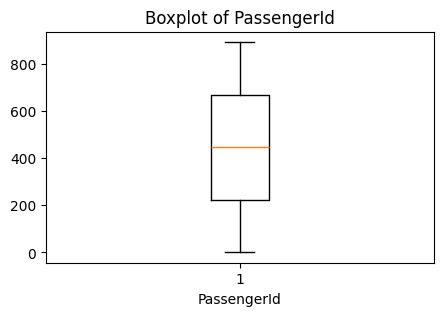

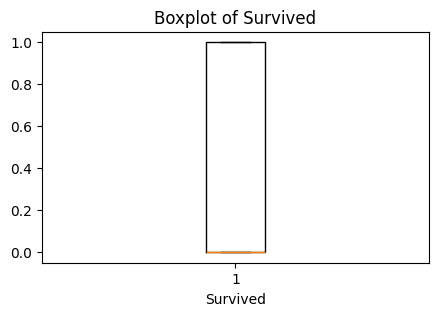

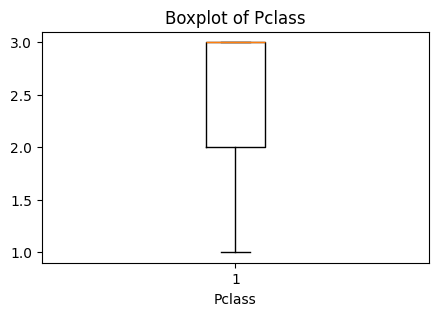

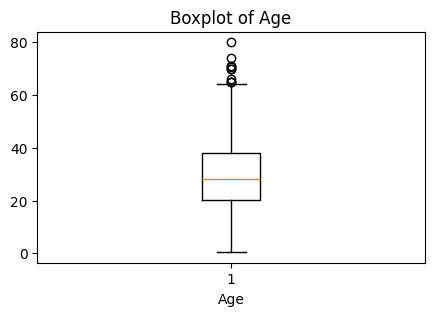

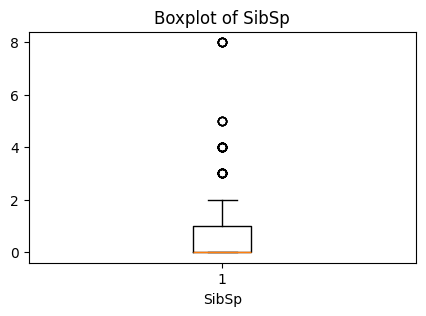

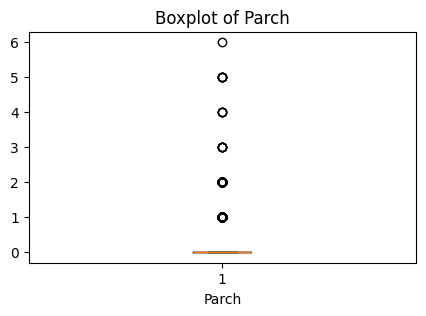

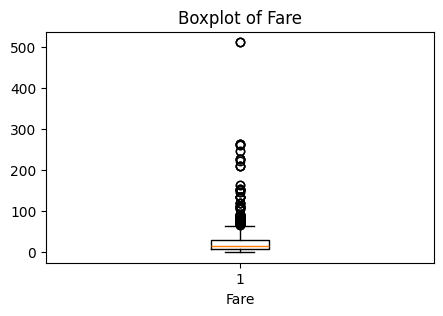

Original Shape : (891, 12)
Shape After Removing Outliers : (436, 12)

Outliers removed successfully.


In [40]:

import matplotlib.pyplot as plt

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure(figsize=(5, 3))
    plt.boxplot(df[col].dropna())
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()


df_clean = df.copy()

for col in num_cols:

    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df_clean = df_clean[
        (df_clean[col] >= lower_limit) &
        (df_clean[col] <= upper_limit)
    ]

print("Original Shape :", df.shape)
print("Shape After Removing Outliers :", df_clean.shape)

# Save Clean Dataset
df_clean.to_csv("Titanic_Cleaned.csv", index=False)

print("\nOutliers removed successfully.")